# Dentix
1. Data processing
2. PCA
3. ...
4. ...
5. ...

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

### 1. Data processing

In [164]:
data = pd.read_csv('datav1.csv')

C:\Users\pablo\AppData\Local\Temp\ipykernel_31864\329314660.py:1: DtypeWarning: Columns (29) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('datav1.csv')


In [136]:
data.isna().sum().sort_values(ascending=False)

Unnamed: 58                                     46324
FINANCIERA                                      46323
TOTAL EGRESOS                                   29547
OPERACION MONEDA EXTRAGERA                      27289
PAGARE_ID                                         539
GASTOS DE SOSTENIMIENTO                           447
EMPRESA                                           181
BARRIO                                              1
ESTADOCIVIL                                         0
PROFESION                                           0
GÉNERO                                              0
ESTRATO                                             0
ANTIGUEDAD EN LA CIUDAD tiempo en residencia        0
NO PERSONAS A CARGO                                 0
TIPO VIVIENDA                                       0
DIRECCION                                           0
ACTIVIDAD ECONÓMICA                                 0
DEPARTAMENTO                                        0
CIUDAD                      

Eliminamos columnas 'obvias'.

In [166]:
drop_cols = [
    'FECHA EXP DOC', 'DIRECCION', 'BARRIO', 'EMPRESA', 'FECHA SOLICITUD',
    'FECHA APROBACIÓN', 'FECHA DESEMBOLSO', 'FCREACION DENTICUOTAS', 'FINANCIERA',
    'LUGAR NACIMIENTO', 'OPERACION MONEDA EXTRAGERA', 'CODIGO CONFIRMACION CREDITO',
    'PAGARE_ID', 'NUMERO CREDITO TESEO', 'SALDO CAPITAL', 'SALDO VENCIDO', 'Unnamed: 58',
    'CIUDAD', 'DIAS DE MORA ', 'NO CREDITO', 'AVAL'
]

data = data.drop(columns= drop_cols)

In [167]:
data = data.drop(columns=['TRANSACTION ID'])

Como la columna de CIUDAD esta sintetizada en la columna de DEPARTAMENTO, vamos a eliminar la columana de CIUDAD(700+ ciudades) y la columna de DEPARTAMENTO(34) la resumiremos a regiones que pertenecen respectivamente[3].

In [168]:
region = {
    'Atlántico': 'Caribe',
    'Magdalena': 'Caribe',
    'Bolívar': 'Caribe',
    'Cesar': 'Caribe',
    'Córdoba': 'Caribe',
    'La Guajira': 'Caribe',
    'Sucre': 'Caribe',

    'Santander': 'Andina',
    'Norte De Santander': 'Andina',
    'Norte de Santander': 'Andina',
    'Bogotá, D.C.': 'Andina',
    'Antioquia': 'Andina',
    'Caldas': 'Andina',
    'Risaralda': 'Andina',
    'Quindío': 'Andina',
    'Boyacá': 'Andina',
    'Cundinamarca': 'Andina',
    'Tolima': 'Andina',
    'Huila': 'Andina',

    'Valle Del Cauca': 'Pacífica',
    'Valle del Cauca': 'Pacífica',
    'Cauca': 'Pacífica',
    'Nariño': 'Pacífica',
    'Chocó': 'Pacífica',

    'Meta': 'Orinoquía',
    'Casanare': 'Orinoquía',
    'Arauca': 'Orinoquía',

    'Amazonas': 'Amazonía',
    'Caquetá': 'Amazonía',
    'Putumayo': 'Amazonía',
    'Guainía': 'Amazonía',
    'Guaviare': 'Amazonía',
    'Vaupés': 'Amazonía',


    'Archipiélago De San Andrés, Providencia Y Santa Catalina': 'Insular'
}

data['REGION'] = data['DEPARTAMENTO'].replace(region)

In [169]:
data = data.drop(columns=['DEPARTAMENTO'])

Ahora cambiamos la columna de fecha de nacimiento por la edad del cliente.

In [170]:
data['FECHA NACIMIENTO'] = pd.to_datetime(data['FECHA NACIMIENTO'], errors='coerce')
data['EDAD'] = (pd.Timestamp.now() - data['FECHA NACIMIENTO']).dt.days // 365
data.drop(columns=['FECHA NACIMIENTO'], inplace=True)
data['EDAD'].isna().sum()

np.int64(841)

Como la columna de TOTAL EGRESOS es una suma de total CUOTA DE CREDITOS y GASTOS DE SOSTENIMIENTO, podemos eliminar ambas columnas, sinembargo, no todos los valores de GASTOS DE SOSTENIMIENTO estan completos, asi que haremos una imputacion de valores usando media proporcional.

In [171]:
ratio = (data['GASTOS DE SOSTENIMIENTO'] / data['TOTAL INGRESOS']).median()
data.loc[data['GASTOS DE SOSTENIMIENTO'].isna(), 'GASTOS DE SOSTENIMIENTO'] = (
    data['TOTAL INGRESOS'] * ratio
)
data.loc[data['TOTAL EGRESOS'].isna(), 'TOTAL EGRESOS'] = (
    data['CUOTA DE CREDITOS'] + data['GASTOS DE SOSTENIMIENTO']
)

data = data.drop(columns=['CUOTA DE CREDITOS', 'GASTOS DE SOSTENIMIENTO'])

In [172]:
data.isna().sum().sort_values(ascending=False)

EDAD                                            841
ESTADOCIVIL                                       0
NIVEL ESTUDIOS                                    0
PROFESION                                         0
GÉNERO                                            0
NO PERSONAS A CARGO                               0
TIPO VIVIENDA                                     0
ESTRATO                                           0
ACTIVIDAD ECONÓMICA                               0
TIPO CONTRATO                                     0
ANTIGUEDAD EN LA CIUDAD tiempo en residencia      0
TIEMPO ACTIVIDAD                                  0
INGRESOS FIJOS                                    0
OTROS INGRESOS                                    0
TOTAL INGRESOS                                    0
TOTAL EGRESOS                                     0
ACTIVOS                                           0
PASIVOS                                           0
OCUPACIÓN                                         0
MONTO PREAPR

Los unicos valores que son 'na' pertenecen a EDAD, como sin muy pocos(porcentualmente), los podemos eliminar del data set.

In [173]:
data = data.dropna()

Hacemos ultimo check: las columnas de INGRESOS FIJOS y OTROS INGRESOS se suman y dan la columna de TOTAL INGRESOS, tambien las podemos eliminar.

In [174]:
data = data.drop(columns=['INGRESOS FIJOS', 'OTROS INGRESOS'])

In [175]:
data.isna().sum().sort_values(ascending=False)

NIVEL ESTUDIOS                                  0
ESTADOCIVIL                                     0
PROFESION                                       0
GÉNERO                                          0
TIPO VIVIENDA                                   0
NO PERSONAS A CARGO                             0
ANTIGUEDAD EN LA CIUDAD tiempo en residencia    0
ESTRATO                                         0
ACTIVIDAD ECONÓMICA                             0
TIPO CONTRATO                                   0
OCUPACIÓN                                       0
TIEMPO ACTIVIDAD                                0
TOTAL INGRESOS                                  0
TOTAL EGRESOS                                   0
ACTIVOS                                         0
PASIVOS                                         0
MONTO PREAPROBADO                               0
MONTO APROBADO                                  0
PLAZO                                           0
MONTO DESEMBOLSO                                0


Hora cambiamos el tipo de dato a las columnas categoricas y las hacemos dummies respectivamente(texto).
- NIVEL ESTUDIO: cat 9 niveles (D)
- ESTADOCIVIL: cat 5 niveles (D)
- PROFESION: cat 416 niveles (muchos niveles)(D)
- ACTIVIDAD ECONÓMICA: cat 10 niveles (D)
- TIPO CONTRATO: cat 4 niveles (D)
- OCUPACIÓN: cat 8 niveles (D)
- COMERCIAL: cat 720 niveles (D)
- CLINICA: cat 52 nivels (D)
- INCIDENCIAFORMALIZACION: cat 18 niveles (D)
- IDENTIFICACION COMERCIAL: cat 541 niveles 
- CODIGO CIIU: cat 9 niveles
- GÉNERO: cat 4 niveles
- TIPO VIVIENDA: cat 4 niveles
- NO PERSONAS A CARGO: cat 9 niveles
- ESTRATO: cat 6 niveles
- REGION: cat 6 niveles

In [177]:
print(len(data['REGION'].value_counts()))
print(data['REGION'].value_counts())

6
REGION
Andina       28870
Caribe       10286
Pacífica      5538
Orinoquía      737
Amazonía        41
Insular         11
Name: count, dtype: int64


In [178]:
vars_dummies = [
    'NIVEL ESTUDIOS', 'ESTADOCIVIL', 'ACTIVIDAD ECONÓMICA', 'TIPO CONTRATO',
    'OCUPACIÓN', 'INCIDENCIAFORMALIZACION', 'CODIGO CIIU', 'GÉNERO',
    'TIPO VIVIENDA', 'NO PERSONAS A CARGO', 'ESTRATO', 'REGION'
]
vars_cats = [
    'PROFESION', 'COMERCIAL', 'CLINICA', 'IDENTIFICACION COMERCIAL'
]
for col in vars_dummies + vars_cats:
    data[col] = data[col].astype('category')

In [179]:
data_dummies = pd.get_dummies(data, columns=vars_dummies, drop_first=True)

In [180]:
data.columns

Index(['NIVEL ESTUDIOS', 'ESTADOCIVIL', 'PROFESION', 'GÉNERO', 'TIPO VIVIENDA',
       'NO PERSONAS A CARGO', 'ANTIGUEDAD EN LA CIUDAD tiempo en residencia',
       'ESTRATO', 'ACTIVIDAD ECONÓMICA', 'TIPO CONTRATO', 'OCUPACIÓN',
       'TIEMPO ACTIVIDAD', 'TOTAL INGRESOS', 'TOTAL EGRESOS', 'ACTIVOS',
       'PASIVOS', 'MONTO PREAPROBADO', 'MONTO APROBADO', 'PLAZO',
       'MONTO DESEMBOLSO', 'COMERCIAL', 'CLINICA', 'IDENTIFICACION COMERCIAL',
       'TASA', 'CUOTAMENSUAL', 'CODIGO CIIU', 'INCIDENCIAFORMALIZACION',
       'SCORE', 'SEGURO', 'DESISTIMIENTO', 'FRANJA DE MORA', 'REGION', 'EDAD'],
      dtype='object')

In [181]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45483 entries, 0 to 46323
Data columns (total 33 columns):
 #   Column                                        Non-Null Count  Dtype   
---  ------                                        --------------  -----   
 0   NIVEL ESTUDIOS                                45483 non-null  category
 1   ESTADOCIVIL                                   45483 non-null  category
 2   PROFESION                                     45483 non-null  category
 3   GÉNERO                                        45483 non-null  category
 4   TIPO VIVIENDA                                 45483 non-null  category
 5   NO PERSONAS A CARGO                           45483 non-null  category
 6   ANTIGUEDAD EN LA CIUDAD tiempo en residencia  45483 non-null  float64 
 7   ESTRATO                                       45483 non-null  category
 8   ACTIVIDAD ECONÓMICA                           45483 non-null  category
 9   TIPO CONTRATO                                 45483 non

### Ahora hacemos feature selection

Primero lo hacemos sin las variables categoricas para evitar ruido de todas las dummies generadas.

In [182]:
Y = data['FRANJA DE MORA'].astype(str)
le = LabelEncoder()
Y_encoded = le.fit_transform(Y)

In [196]:
X1_drop = vars_cats + vars_dummies + ['FRANJA DE MORA']
X1 = data.drop(columns=X1_drop)
scaler = StandardScaler()
X1s = scaler.fit_transform(X1)
X_train, X_test, y_train, y_test = train_test_split(X1s, Y_encoded, train_size=10000, stratify=Y_encoded, random_state=0)
knn = KNeighborsClassifier(n_neighbors=5)
sfs = SequentialFeatureSelector(knn, n_features_to_select=10, direction='forward', cv=3, n_jobs=-1)
sfs.fit(X_train, y_train)
print(sfs.get_support())
print(sfs.transform(X1s).shape)

selected_mask = sfs.get_support()
selected_features = X1.columns[selected_mask]
print("Variables seleccionadas:", len(selected_features))
print(selected_features)

[ True  True  True  True  True  True False False  True False  True  True
 False False  True False]
(45483, 10)
Variables seleccionadas: 10
Index(['ANTIGUEDAD EN LA CIUDAD tiempo en residencia', 'TIEMPO ACTIVIDAD',
       'TOTAL INGRESOS', 'TOTAL EGRESOS', 'ACTIVOS', 'PASIVOS', 'PLAZO',
       'TASA', 'CUOTAMENSUAL', 'DESISTIMIENTO'],
      dtype='object')


Ahora incluimos las dummies al dataset para observar su impacto/relevancia

In [191]:
X2_drop = ['FRANJA DE MORA'] + vars_cats
X2 = data_dummies.drop(columns=X2_drop)
scaler = StandardScaler()
X2s = scaler.fit_transform(X2)

X_train, X_test, y_train, y_test = train_test_split(X2s, Y_encoded, train_size=10000, stratify=Y_encoded, random_state=0)
knn = KNeighborsClassifier(n_neighbors=5)
sfs = SequentialFeatureSelector(knn, n_features_to_select=20, direction='forward', cv=3, n_jobs=-1)
sfs.fit(X_train, y_train)
print(sfs.get_support())
print(sfs.transform(X2s).shape)

selected_mask = sfs.get_support()
selected_features = X2.columns[selected_mask]
print("Variables seleccionadas:", len(selected_features))
print(selected_features)

[False False False False False False False False False False False  True
 False False  True False  True  True False  True  True False  True  True
  True False False False False False False False False False False False
  True False False  True False  True False False False  True False False
  True  True False False False False False False False False False False
 False False False False False False False False False  True False False
 False False False  True False False False False False False False False
 False False  True False  True False False False False  True False False]
(45483, 20)
Variables seleccionadas: 20
Index(['CUOTAMENSUAL', 'DESISTIMIENTO',
       'NIVEL ESTUDIOS_Doctorado / Postdoctorado',
       'NIVEL ESTUDIOS_Especialización', 'NIVEL ESTUDIOS_Maestría',
       'NIVEL ESTUDIOS_Primaria', 'NIVEL ESTUDIOS_Técnico',
       'NIVEL ESTUDIOS_Universitario',
       'ESTADOCIVIL_Divorciado (a) / Separado (a)',
       'ACTIVIDAD ECONÓMICA_Villa turbay', 'TIPO CONTRATO_3',
   

### Matriz de Correlacion

DIAS DE MORA                1.000000
SALDO VENCIDO               0.217327
SALDO CAPITAL               0.101161
PLAZO                       0.054399
TASA                        0.042496
NO CREDITO                  0.018304
CODIGO CIIU                 0.014325
IDENTIFICACION COMERCIAL    0.009460
TIPO VIVIENDA               0.006875
OTROS INGRESOS              0.005956
TOTAL INGRESOS              0.005326
INGRESOS FIJOS              0.005283
NO PERSONAS A CARGO         0.004959
TIPO CONTRATO               0.003278
PAGARE_ID                   0.003207
Name: DIAS DE MORA , dtype: float64


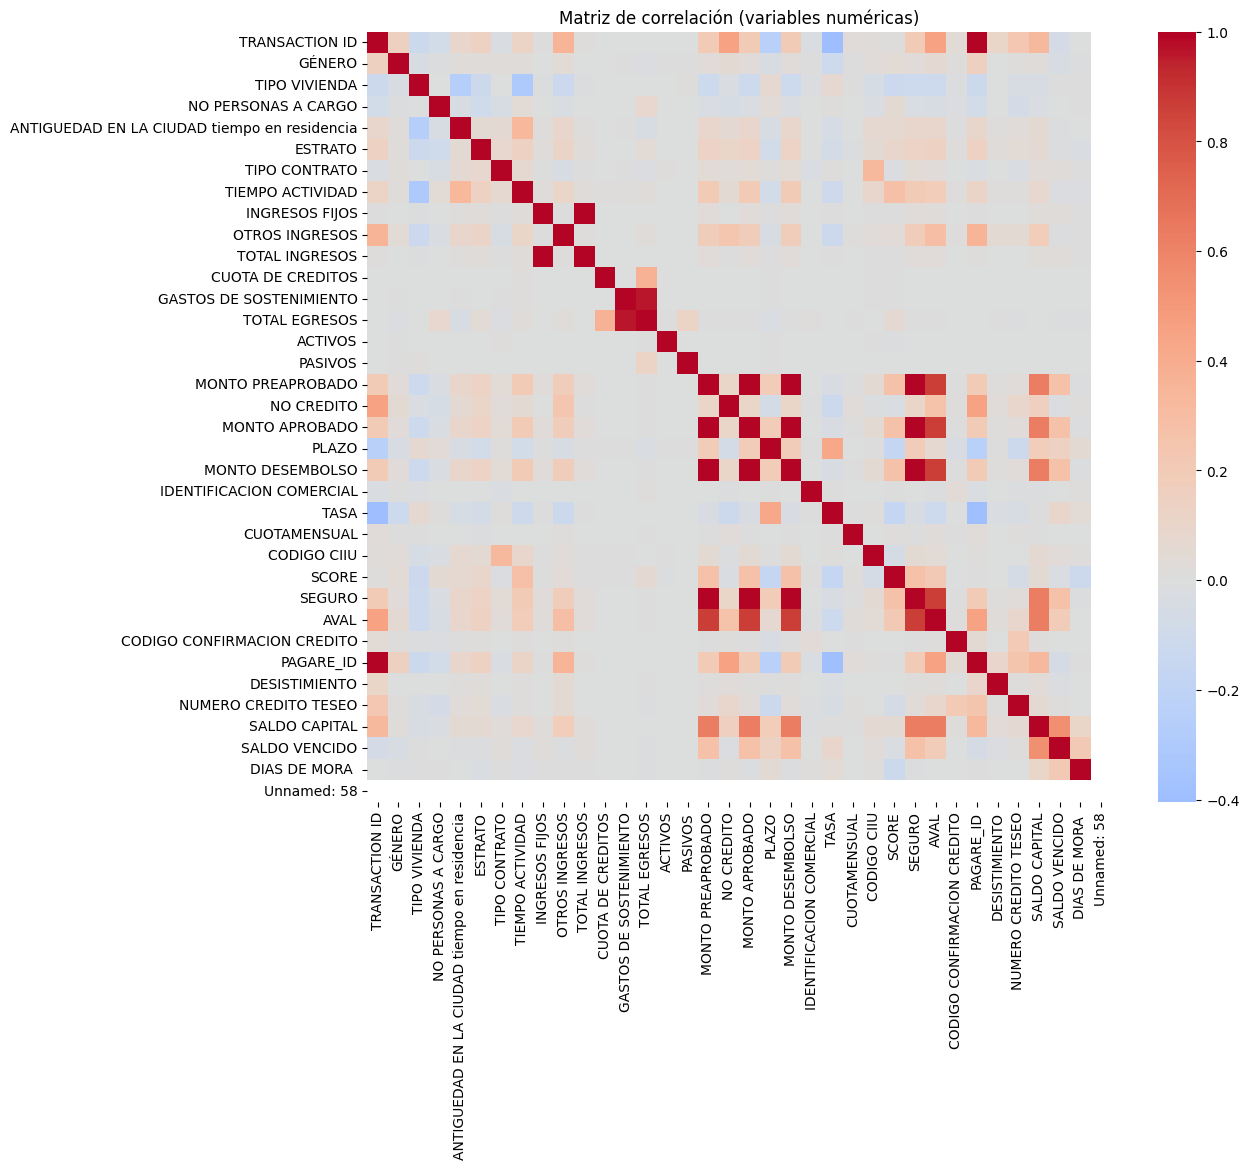

In [ ]:
num_cols = data.select_dtypes(include=['number']).columns

corr = data[num_cols].corr()

print(corr['DIAS DE MORA '].sort_values(ascending=False).head(15))

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Matriz de correlación (variables numéricas)')
plt.show()

### 2. PCA

### 3. ...

### 4. ...

### 5. ...